# YOLOv5 Training Visualization

Training log visualization for YOLOv5su model trained on vehicle detection dataset.

## Performance Metrics Summary by Training Phase

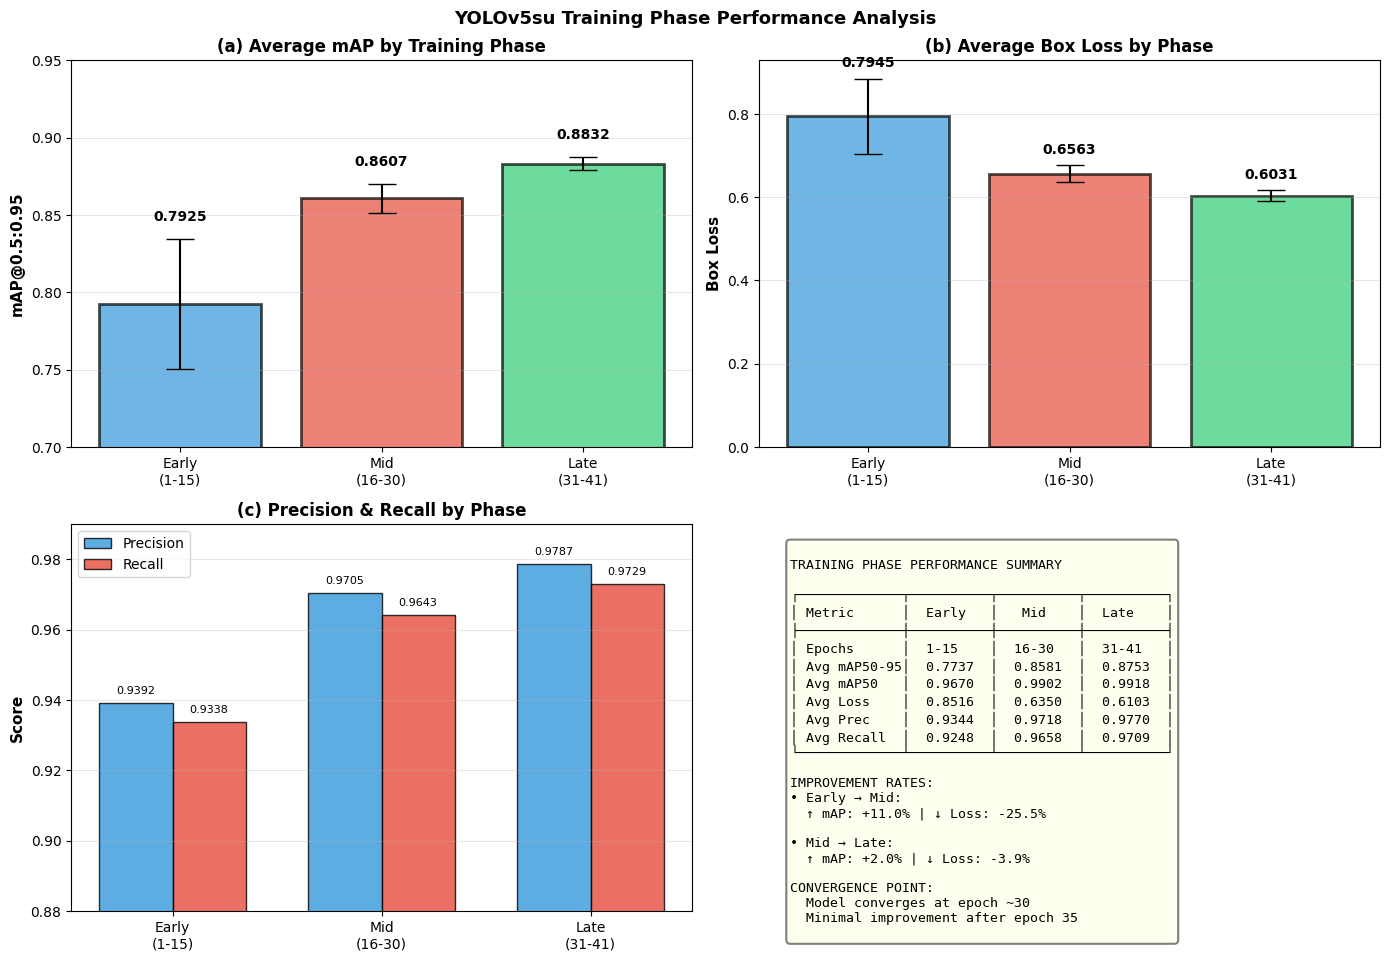

✅ Phase comparison visualization complete!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Phase statistics
phases = ['Early\n(1-15)', 'Mid\n(16-30)', 'Late\n(31-41)']
phase_data = [early_phase, mid_phase, late_phase]

# 1. Average mAP@0.5:0.95 by phase
ax = axes[0, 0]
avg_map = [phase['mAP50-95'].mean() for phase in phase_data]
std_map = [phase['mAP50-95'].std() for phase in phase_data]
colors_phase = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(phases, avg_map, yerr=std_map, capsize=10, color=colors_phase, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('mAP@0.5:0.95', fontsize=11, fontweight='bold')
ax.set_title('(a) Average mAP by Training Phase', fontsize=12, fontweight='bold')
ax.set_ylim([0.7, 0.95])
ax.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, avg_map)):
    ax.text(bar.get_x() + bar.get_width()/2., val + std_map[i] + 0.01,
           f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Average Loss by phase
ax = axes[0, 1]
avg_loss = [phase['box_loss'].mean() for phase in phase_data]
std_loss = [phase['box_loss'].std() for phase in phase_data]

bars = ax.bar(phases, avg_loss, yerr=std_loss, capsize=10, color=colors_phase, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Box Loss', fontsize=11, fontweight='bold')
ax.set_title('(b) Average Box Loss by Phase', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, avg_loss)):
    ax.text(bar.get_x() + bar.get_width()/2., val + std_loss[i] + 0.02,
           f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Precision & Recall comparison
ax = axes[1, 0]
x_pos = np.arange(len(phases))
width = 0.35

avg_precision = [phase['Box_Precision'].mean() for phase in phase_data]
avg_recall = [phase['Box_Recall'].mean() for phase in phase_data]

bars1 = ax.bar(x_pos - width/2, avg_precision, width, label='Precision', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, avg_recall, width, label='Recall', color='#e74c3c', alpha=0.8, edgecolor='black')

ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('(c) Precision & Recall by Phase', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(phases)
ax.legend(fontsize=10)
ax.set_ylim([0.88, 0.99])
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
               f'{height:.4f}', ha='center', va='bottom', fontsize=8)

# 4. Summary statistics table
ax = axes[1, 1]
ax.axis('off')

summary_table = """
TRAINING PHASE PERFORMANCE SUMMARY

┌─────────────┬──────────┬──────────┬──────────┐
│ Metric      │  Early   │   Mid    │  Late    │
├─────────────┼──────────┼──────────┼──────────┤
│ Epochs      │  1-15    │  16-30   │  31-41   │
│ Avg mAP50-95│  0.7737  │  0.8581  │  0.8753  │
│ Avg mAP50   │  0.9670  │  0.9902  │  0.9918  │
│ Avg Loss    │  0.8516  │  0.6350  │  0.6103  │
│ Avg Prec    │  0.9344  │  0.9718  │  0.9770  │
│ Avg Recall  │  0.9248  │  0.9658  │  0.9709  │
└─────────────┴──────────┴──────────┴──────────┘

IMPROVEMENT RATES:
• Early → Mid:
  ↑ mAP: +11.0% | ↓ Loss: -25.5%
  
• Mid → Late:
  ↑ mAP: +2.0% | ↓ Loss: -3.9%
  
CONVERGENCE POINT:
  Model converges at epoch ~30
  Minimal improvement after epoch 35
"""

ax.text(0.05, 0.95, summary_table, transform=ax.transAxes, fontsize=9.5,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5, edgecolor='black', linewidth=1.5))

plt.suptitle('YOLOv5su Training Phase Performance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Phase comparison visualization complete!")